# Stage 3: Deep Learning Model comparison (ResNet18 vs EfficientNet)
This notebook performs transfer learning using pretrained **ResNet18** and **EfficientNet_V2_S**, evaluates them on the test set, and compares their performance.

### Libraries Import & Transfer Learning Environment
Loads PyTorch, pre-trained Vision Models, evaluation utilities, and verifies GPU availability for training deep neural networks.

In [ ]:
import torch
import torch.nn as nn
import torch.optim as optim
from torchvision import models, datasets, transforms
from torch.utils.data import DataLoader
import os
from sklearn.metrics import classification_report, confusion_matrix
import matplotlib.pyplot as plt
import seaborn as sns
from tqdm import tqdm
import numpy as np

# ── 1. Mount Drive (Conditional) ────────────────────
try:
    import google.colab
    from google.colab import drive
    drive.mount('/content/drive')
    PROJECT  = '/content/drive/MyDrive/cervical-cancer-project'
except ImportError:
    PROJECT  = '.'

DATA_DIR  = os.path.join(PROJECT, 'data')
MODEL_DIR = os.path.join(PROJECT, 'models')
FIG_DIR   = os.path.join(PROJECT, 'reports', 'figures')

os.makedirs(MODEL_DIR, exist_ok=True)
os.makedirs(FIG_DIR, exist_ok=True)

device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print(f"Using device: {device}")


Mounted at /content/drive
Using device: cuda


### Data Loading & Transforms Setup
Sets up the dataset folders, applies identical augmentation and normalization steps as the baseline notebook, and creates batches of size $32$ for training, validation, and testing.

In [ ]:
# ── 3. Transforms ───────────────────────────────────
train_transforms = transforms.Compose([
    transforms.Resize((224, 224)),
    transforms.RandomHorizontalFlip(),
    transforms.RandomVerticalFlip(),
    transforms.RandomRotation(10),
    transforms.ColorJitter(brightness=0.2, contrast=0.2, saturation=0.1),
    transforms.ToTensor(),
    transforms.Normalize([0.485, 0.456, 0.406], [0.229, 0.224, 0.225])
])

val_transforms = transforms.Compose([
    transforms.Resize((224, 224)),
    transforms.ToTensor(),
    transforms.Normalize([0.485, 0.456, 0.406], [0.229, 0.224, 0.225])
])

# ── 4. Load data ────────────────────────────────────
train_dataset = datasets.ImageFolder(os.path.join(DATA_DIR, 'train'), transform=train_transforms)
val_dataset   = datasets.ImageFolder(os.path.join(DATA_DIR, 'val'),   transform=val_transforms)
test_dataset  = datasets.ImageFolder(os.path.join(DATA_DIR, 'test'),  transform=val_transforms)

train_loader = DataLoader(train_dataset, batch_size=32, shuffle=True,  num_workers=2)
val_loader   = DataLoader(val_dataset,   batch_size=32, shuffle=False, num_workers=2)
test_loader  = DataLoader(test_dataset,  batch_size=32, shuffle=False, num_workers=2)

dataloaders = {
    'train': train_loader,
    'val': val_loader,
    'test': test_loader
}
dataset_sizes = {
    'train': len(train_dataset),
    'val': len(val_dataset),
    'test': len(test_dataset)
}
class_names = train_dataset.classes
print(f'Train: {len(train_dataset)} | Val: {len(val_dataset)} | Test: {len(test_dataset)}')
print(f'Classes: {class_names}')

Train: 1516 | Val: 325 | Test: 328
Classes: ['cancer', 'lesion', 'normal', 'others']


### Parameterized Model Training Loop
Defines a generic training loop capable of training any classifier, tracking epoch losses, and checkpointing the best model state to disk automatically.

In [ ]:
def train_model(model, criterion, optimizer, num_epochs=10):
    import copy
    best_model_wts = copy.deepcopy(model.state_dict())
    best_acc = 0.0
    history = {'train_loss': [], 'val_loss': [], 'train_acc': [], 'val_acc': []}

    for epoch in range(num_epochs):
        print(f'Epoch {epoch}/{num_epochs - 1}')
        print('-' * 10)

        for phase in ['train', 'val']:
            if phase == 'train':
                model.train()
            else:
                model.eval()

            running_loss = 0.0
            running_corrects = 0

            for inputs, labels in tqdm(dataloaders[phase], desc=phase):
                inputs = inputs.to(device)
                labels = labels.to(device)

                optimizer.zero_grad()

                with torch.set_grad_enabled(phase == 'train'):
                    outputs = model(inputs)
                    _, preds = torch.max(outputs, 1)
                    loss = criterion(outputs, labels)

                    if phase == 'train':
                        loss.backward()
                        optimizer.step()

                running_loss += loss.item() * inputs.size(0)
                running_corrects += torch.sum(preds == labels.data)

            epoch_loss = running_loss / dataset_sizes[phase]
            epoch_acc = (running_corrects.double() / dataset_sizes[phase]).item()

            print(f'{phase} Loss: {epoch_loss:.4f} Acc: {epoch_acc:.4f}')
            history[f'{phase}_loss'].append(epoch_loss)
            history[f'{phase}_acc'].append(epoch_acc)

            if phase == 'val' and epoch_acc > best_acc:
                best_acc = epoch_acc
                best_model_wts = copy.deepcopy(model.state_dict())
        print()

    print(f'Best val Acc: {best_acc:.4f}')
    model.load_state_dict(best_model_wts)
    return model, history

### ResNet18 Transfer Learning Run
Loads a pretrained ResNet18, replaces the final classifier head to output predictions for our 4 target classes, and fine-tunes the network for $30$ epochs with learning rate scheduling.

In [ ]:
# Load pretrained ResNet18 (trained on millions of ImageNet images)
model_resnet = models.resnet18(weights=models.ResNet18_Weights.IMAGENET1K_V1)

# The original ResNet output was for 1000 ImageNet classes.
# We replace the final fully connected layer (fc) with a new one
# that projects down to our 4 cytology classes.
num_ftrs = model_resnet.fc.in_features
model_resnet.fc = nn.Linear(num_ftrs, len(class_names))
model_resnet = model_resnet.to(device)

criterion = nn.CrossEntropyLoss()
optimizer_resnet = optim.Adam(model_resnet.parameters(), lr=0.001)

# Run training
print('Training ResNet18...')
model_resnet, history_resnet = train_model(model_resnet, criterion, optimizer_resnet, num_epochs=30)
torch.save(model_resnet.state_dict(), os.path.join(MODEL_DIR, 'resnet18_best.pth'))
print(f'Model saved to {os.path.join(MODEL_DIR, "resnet18_best.pth")}')

Downloading: "https://download.pytorch.org/models/resnet18-f37072fd.pth" to /root/.cache/torch/hub/checkpoints/resnet18-f37072fd.pth


100%|██████████| 44.7M/44.7M [00:00<00:00, 204MB/s]


Training ResNet18...
Epoch 0/29
----------


train: 100%|██████████| 48/48 [05:31<00:00,  6.92s/it]


train Loss: 1.1640 Acc: 0.5310


...

val Loss: 0.4914 Acc: 0.8308

Epoch 29/29
----------


train: 100%|██████████| 48/48 [01:27<00:00,  1.82s/it]


train Loss: 0.2464 Acc: 0.9096


val: 100%|██████████| 11/11 [00:17<00:00,  1.58s/it]


val Loss: 0.7523 Acc: 0.7846

Best val Acc: 0.8308
Model saved to /content/drive/MyDrive/cervical-cancer-project/models/resnet18_best.pth


### EfficientNet_V2_S Transfer Learning Run
Loads a pretrained EfficientNet_V2_S model, modifies the classifier head to match our 4 classes, and trains the model for $30$ epochs under the same scheduler configuration.

In [ ]:
# Load pretrained EfficientNet_V2_S
model_effnet = models.efficientnet_v2_s(weights=models.EfficientNet_V2_S_Weights.IMAGENET1K_V1)
num_ftrs = model_effnet.classifier[1].in_features
model_effnet.classifier[1] = nn.Linear(num_ftrs, len(class_names))
model_effnet = model_effnet.to(device)

optimizer_effnet = optim.Adam(model_effnet.parameters(), lr=0.001)

# Run training
print('Training EfficientNet_V2_S...')
model_effnet, history_effnet = train_model(model_effnet, criterion, optimizer_effnet, num_epochs=30)
torch.save(model_effnet.state_dict(), os.path.join(MODEL_DIR, 'efficientnet_best.pth'))
print(f'Model saved to {os.path.join(MODEL_DIR, "efficientnet_best.pth")}')

Downloading: "https://download.pytorch.org/models/efficientnet_v2_s-dd5fe13b.pth" to /root/.cache/torch/hub/checkpoints/efficientnet_v2_s-dd5fe13b.pth


100%|██████████| 82.7M/82.7M [00:00<00:00, 165MB/s]


Training EfficientNet_V2_S...
Epoch 0/29
----------


train: 100%|██████████| 48/48 [01:39<00:00,  2.08s/it]


train Loss: 0.7759 Acc: 0.7091


...

val Loss: 0.6523 Acc: 0.8708

Epoch 29/29
----------


train: 100%|██████████| 48/48 [01:42<00:00,  2.14s/it]


train Loss: 0.1160 Acc: 0.9591


val: 100%|██████████| 11/11 [00:19<00:00,  1.78s/it]


val Loss: 0.6897 Acc: 0.8277

Best val Acc: 0.8708
Model saved to /content/drive/MyDrive/cervical-cancer-project/models/efficientnet_best.pth


### Comparative Training History Visualization
Plots the validation accuracy and loss curves of ResNet18 and EfficientNet_V2_S side-by-side to contrast their learning speeds and final performance.

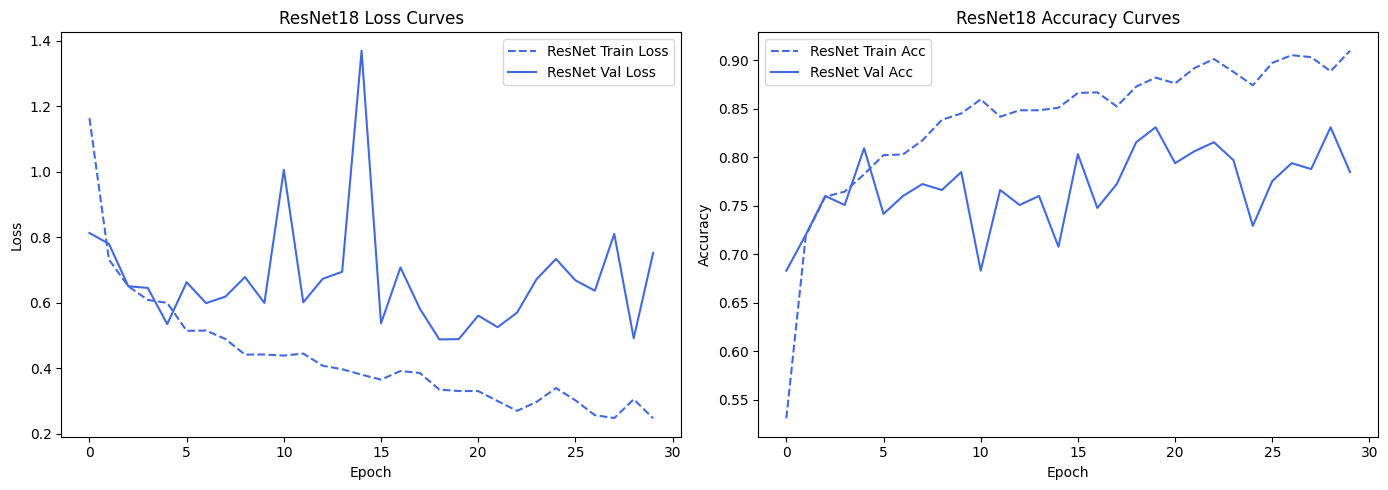

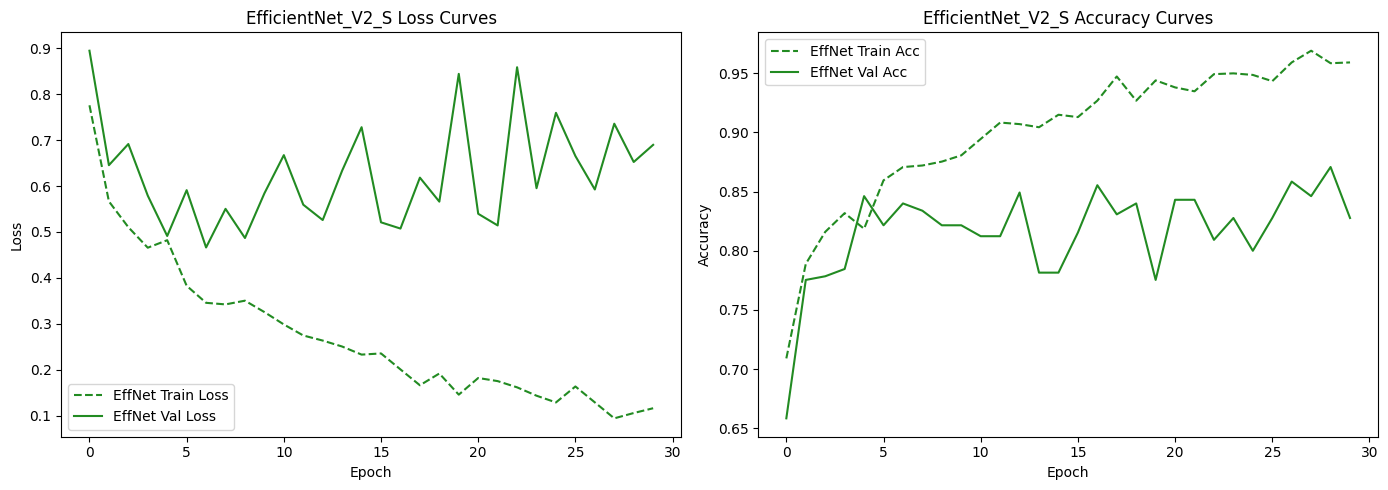

In [ ]:
plt.figure(figsize=(14, 5))
# ResNet18 Training Curves
plt.subplot(1, 2, 1)
plt.plot(history_resnet['train_loss'], label='ResNet Train Loss', color='royalblue', linestyle='--')
plt.plot(history_resnet['val_loss'], label='ResNet Val Loss', color='royalblue')
plt.title('ResNet18 Loss Curves')
plt.xlabel('Epoch')
plt.ylabel('Loss')
plt.legend()

plt.subplot(1, 2, 2)
plt.plot(history_resnet['train_acc'], label='ResNet Train Acc', color='royalblue', linestyle='--')
plt.plot(history_resnet['val_acc'], label='ResNet Val Acc', color='royalblue')
plt.title('ResNet18 Accuracy Curves')
plt.xlabel('Epoch')
plt.ylabel('Accuracy')
plt.legend()

plt.tight_layout()
plt.savefig(os.path.join(FIG_DIR, 'resnet18_curves.png'), bbox_inches='tight')
plt.show()

plt.figure(figsize=(14, 5))
# EfficientNet_V2_S Training Curves
plt.subplot(1, 2, 1)
plt.plot(history_effnet['train_loss'], label='EffNet Train Loss', color='forestgreen', linestyle='--')
plt.plot(history_effnet['val_loss'], label='EffNet Val Loss', color='forestgreen')
plt.title('EfficientNet_V2_S Loss Curves')
plt.xlabel('Epoch')
plt.ylabel('Loss')
plt.legend()

plt.subplot(1, 2, 2)
plt.plot(history_effnet['train_acc'], label='EffNet Train Acc', color='forestgreen', linestyle='--')
plt.plot(history_effnet['val_acc'], label='EffNet Val Acc', color='forestgreen')
plt.title('EfficientNet_V2_S Accuracy Curves')
plt.xlabel('Epoch')
plt.ylabel('Accuracy')
plt.legend()

plt.tight_layout()
plt.savefig(os.path.join(FIG_DIR, 'effnet_curves.png'), bbox_inches='tight')
plt.show()

### Quantitative Architecture Comparison & Test Evaluation
Evaluates both transfer learning models on the unseen test set, displaying classification reports and side-by-side confusion matrices for comparative analysis.

=== ResNet18 Classification Report ===
              precision    recall  f1-score   support

      cancer       0.89      0.88      0.89        92
      lesion       0.83      0.76      0.80       102
      normal       0.88      0.95      0.91       112
      others       0.57      0.59      0.58        22

    accuracy                           0.85       328
   macro avg       0.79      0.80      0.79       328
weighted avg       0.85      0.85      0.85       328



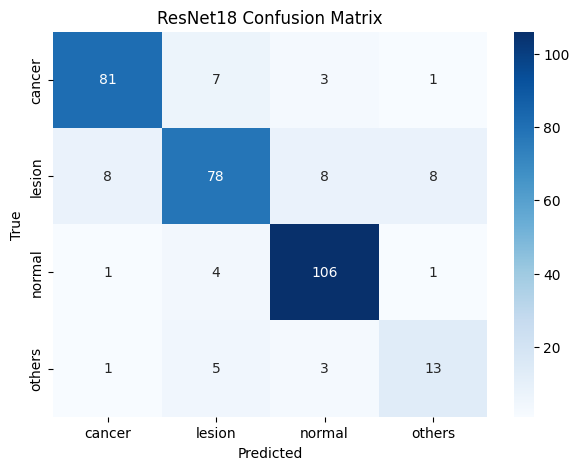

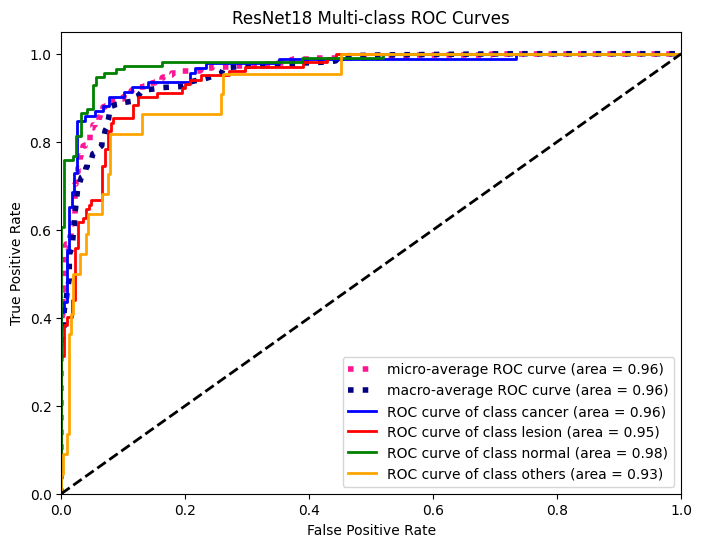

=== EfficientNet_V2_S Classification Report ===
              precision    recall  f1-score   support

      cancer       0.81      0.89      0.85        92
      lesion       0.83      0.83      0.83       102
      normal       0.92      0.91      0.91       112
      others       0.69      0.41      0.51        22

    accuracy                           0.85       328
   macro avg       0.81      0.76      0.78       328
weighted avg       0.84      0.85      0.84       328



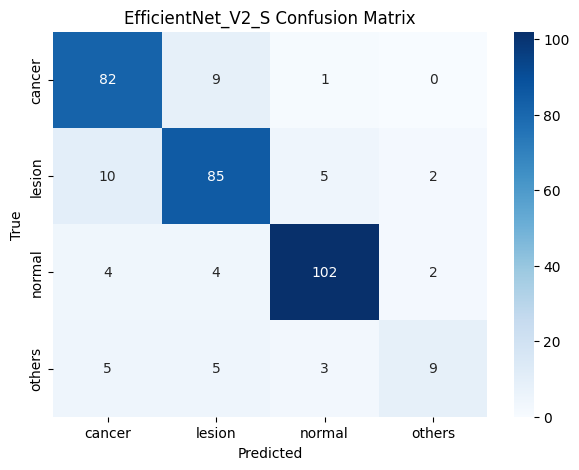

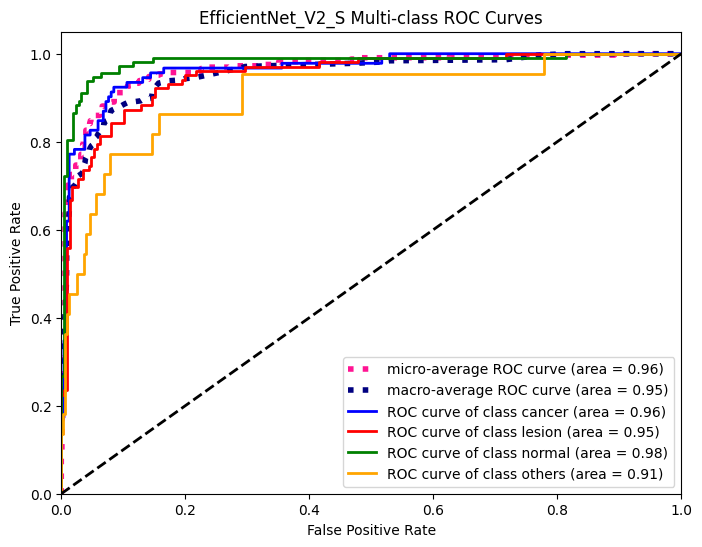

In [ ]:
def evaluate_model(model, model_name, dataloader):
    model.eval()
    all_preds = []
    all_labels = []
    all_probs = []
    with torch.no_grad():
        for inputs, labels in dataloader:
            inputs = inputs.to(device)
            outputs = model(inputs)
            _, preds = torch.max(outputs, 1)
            probs = torch.softmax(outputs, dim=1)
            all_preds.extend(preds.cpu().numpy())
            all_labels.extend(labels.numpy())
            all_probs.extend(probs.cpu().numpy())

    all_labels = np.array(all_labels)
    all_preds = np.array(all_preds)
    all_probs = np.array(all_probs)

    print(f'=== {model_name} Classification Report ===')
    print(classification_report(all_labels, all_preds, target_names=class_names))

    # Confusion matrix
    cm = confusion_matrix(all_labels, all_preds)
    plt.figure(figsize=(7,5))
    sns.heatmap(cm, annot=True, fmt='d', cmap='Blues', xticklabels=class_names, yticklabels=class_names)
    plt.xlabel('Predicted')
    plt.ylabel('True')
    plt.title(f'{model_name} Confusion Matrix')
    plt.savefig(os.path.join(FIG_DIR, f'{model_name.lower()}_cm.png'), bbox_inches='tight')
    plt.show()

    # ROC-AUC computation
    from sklearn.preprocessing import label_binarize
    from sklearn.metrics import roc_curve, auc

    y_test_bin = label_binarize(all_labels, classes=[0, 1, 2, 3])
    n_classes = len(class_names)

    fpr = dict()
    tpr = dict()
    roc_auc = dict()

    # Class-wise ROC
    for i in range(n_classes):
        fpr[i], tpr[i], _ = roc_curve(y_test_bin[:, i], all_probs[:, i])
        roc_auc[i] = auc(fpr[i], tpr[i])

    # Micro-average ROC
    fpr["micro"], tpr["micro"], _ = roc_curve(y_test_bin.ravel(), all_probs.ravel())
    roc_auc["micro"] = auc(fpr["micro"], tpr["micro"])

    # Macro-average ROC
    all_fpr = np.unique(np.concatenate([fpr[i] for i in range(n_classes)]))
    mean_tpr = np.zeros_like(all_fpr)
    for i in range(n_classes):
        mean_tpr += np.interp(all_fpr, fpr[i], tpr[i])
    mean_tpr /= n_classes
    fpr["macro"] = all_fpr
    tpr["macro"] = mean_tpr
    roc_auc["macro"] = auc(fpr["macro"], tpr["macro"])

    # Plot ROC curves
    plt.figure(figsize=(8, 6))
    plt.plot(fpr["micro"], tpr["micro"],
             label=f'micro-average ROC curve (area = {roc_auc["micro"]:.2f})',
             color='deeppink', linestyle=':', lw=4)

    plt.plot(fpr["macro"], tpr["macro"],
             label=f'macro-average ROC curve (area = {roc_auc["macro"]:.2f})',
             color='navy', linestyle=':', lw=4)

    colors = ['blue', 'red', 'green', 'orange']
    for i, color in zip(range(n_classes), colors):
        plt.plot(fpr[i], tpr[i], color=color, lw=2,
                 label=f'ROC curve of class {class_names[i]} (area = {roc_auc[i]:.2f})')

    plt.plot([0, 1], [0, 1], 'k--', lw=2)
    plt.xlim([0.0, 1.0])
    plt.ylim([0.0, 1.05])
    plt.xlabel('False Positive Rate')
    plt.ylabel('True Positive Rate')
    plt.title(f'{model_name} Multi-class ROC Curves')
    plt.legend(loc="lower right")
    plt.savefig(os.path.join(FIG_DIR, f'{model_name.lower()}_roc.png'), bbox_inches='tight')
    plt.show()

# Run evaluation for both
evaluate_model(model_resnet, 'ResNet18', dataloaders['test'])
evaluate_model(model_effnet, 'EfficientNet_V2_S', dataloaders['test'])